# Performance Measures: Confusion Matrices, Precision, and Recall

This notebook picks up where the previous one left off. We already know that **accuracy is misleading** with unbalanced datasets (the dummy model was getting ~90% accuracy without detecting a single 5). Now we're going to use tools that DO tell us the truth about the model.

The steps are:

1. The **confusion matrix**: what the model is confusing and with what
2. **Precision**: when it says "it's a 5," how much should I believe it?
3. **Recall**: of all the real 5s, how many does it catch?
4. The **F1 score**: combining the two into a single number
5. The **trade-off** between precision and recall

## Starting Point

We rebuilt the bare minimum of the previous notebook so that it could run on its own: we downloaded MNIST, assembled the binary target of the "3-detector," and trained the SGD.

In [1]:
from sklearn.datasets import fetch_openml

# as_frame=False to receive NumPy arrays instead of a Pandas DataFrame,
# which isn't convenient to handle with images
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

# MNIST is already split: 60,000 for training, 10,000 for testing
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# We convert the labels (which are '0'..'9') to booleans: True if it's 3
y_train_3 = (y_train == '3')
y_test_3 = (y_test == '3')

In [2]:
from sklearn.linear_model import SGDClassifier

# fixed random_state so that the result is reproducible between runs
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_3)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


## 8. The Confusion Matrix

### The Idea

A confusion matrix counts **how many times the model classified instances of class A as class B**, for each A/B pair.

In our case, there are only two classes (3 and not-3), so the matrix is ​​2 × 2. Each cell answers a different question.

### First, we need clean predictions

We can't use the test set yet (that's for the end of the project). Predicting on the same training data is also useless, because the model has already seen it.

The solution is `cross_val_predict`: it performs cross-validation, but instead of returning a score, **it returns the prediction for each instance made when that instance was in the test fold**. That is, each prediction is *out-of-sample*: the model never saw that data during its training.

In [3]:
from sklearn.model_selection import cross_val_predict

# Same mechanics as cross_val_score, but returns predictions per fold
# instead of the score. Each prediction is out-of-sample.
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_3, cv=3)

Now we pass the actual labels (`y_train_3`) and the predicted labels (`y_train_pred`) to `confusion_matrix`:

In [4]:
from sklearn.metrics import confusion_matrix

# First the actual values, then the predicted values: order matters when reading the matrix
cm = confusion_matrix(y_train_3, y_train_pred)
cm

array([[53477,   392],
       [ 2113,  4018]], dtype=int64)

### How to Read This Matrix

The result looks something like this:

```python
array([[53477,   392],
       [ 2113,  4018]], dtype=int64)
```

The rule is:

> **Each row represents the ACTUAL class, and each column represents the PREDICTED class.**

| | Predicted: NOT-3 | Predicted: 3 |
|---|---|---|
| **Actual: NOT-3** | 53477 (TN) | 392 (FP) |
| **Actual: 3** | 2113 (FN) | 4018 (TP) |

Breaking down the four cells:

- **TN (True Negatives) = 53,477** → The digit was not a 3, and the model predicted not a 3. Correct.
- **FP (False Positives) = 392** → The digit was not a 3, but the model predicted it was a 3. False alarm. (*Type I error*)
- **FN (False Negatives) = 2,113** → The digit was a 3, but the model predicted it was not a 3. Missed detection. (*Type II error*)
- **TP (True Positives) = 4,018** → The digit was a 3, and the model correctly predicted it was a 3.

**Tip:** The second word (**Positive** or **Negative**) tells you what the model **predicted**. The first word (**True** or **False**) tells you whether that prediction was **correct**.

To put it more clearly, a **perfect** classifier would only have values ​​on the diagonal (TN and TP), and zeros for errors:

In [5]:
# We pass on the real labels as if they were predictions:
# simulate a model that never makes mistakes
y_train_perfect_predictions = y_train_3
confusion_matrix(y_train_3, y_train_perfect_predictions)

array([[53869,     0],
       [    0,  6131]], dtype=int64)

As expected, the 392 false positives and the 2,113 false negatives disappear. Every sample is classified correctly, so all counts move to the main diagonal of the confusion matrix, where predicted labels match the actual labels.

### Visualizing the Matrix

Reading numbers directly is difficult. Scikit-Learn provides a display that draws it:

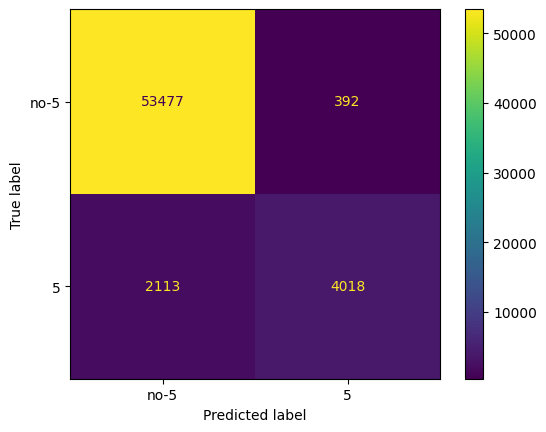

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Draw the matrix as a heatmap, easier to interpret at a glance
ConfusionMatrixDisplay.from_predictions(y_train_3, y_train_pred,
                                        display_labels=["no-5", "5"])
plt.show()

## 9. Precision

The confusion matrix provides a lot of information, but sometimes we want a single metric. One of the most important is **Precision**.

> **Precision = Of all the samples predicted as positive, what fraction were actually positive?**

$\text{Precision} = \frac{TP}{TP + FP}$

In other words:

> **When the model says "It's a 5", how often is it correct?**

Using our confusion matrix:

- **TP (True Positives)** = 4,018
- **FP (False Positives)** = 392

$\text{Precision} = \frac{4018}{4018 + 392}$

$\text{Precision} = \frac{4018}{4410}$

$\text{Precision} \approx 0.911$

This means that when the model predicts **"3"**, it is correct about **91.1%** of the time.

### The Trick of Deceptive Precision

Precision alone can be inflated. Imagine a model that almost always says "no," and only says "yes, it's a 3" for the single image it's absolutely certain about.

If it gets that single prediction right → precision = 1/1 = **100%**.

It sounds perfect, but it's useless: it ignored all the other 5s in the dataset. That's why precision **never stands alone**: we always use recall.

In [7]:
from sklearn.metrics import precision_score

# This is equivalent to calculating 4018 / (392 + 4018) by hand
precision_score(y_train_3, y_train_pred)

0.9111111111111111

## 10. Recall

**Recall** (also called **Sensitivity** or **True Positive Rate**) looks at the problem from the opposite perspective.

> **Recall = Of all the actual positive samples, what fraction did the model correctly identify?**

$\text{Recall} = \frac{TP}{TP + FN}$

In other words:

> **Of all the actual 3s, how many did the model successfully detect?**

Using our confusion matrix:

- **TP (True Positives)** = 4,018
- **FN (False Negatives)** = 2,113

$\text{Recall} = \frac{4018}{4018 + 2113}$

$\text{Recall} = \frac{4018}{6131}$

$\text{Recall} \approx 0.655$

This means that the model successfully detected about **65.5%** of all the actual 5s, while missing the remaining **34.5%**.

In [8]:
from sklearn.metrics import recall_score

# Equivalent to 4018 / (2113 + 4018)
recall_score(y_train_3, y_train_pred)

0.655358016636764

### The Model Doesn't Look So Brilliant Anymore

When we looked only at **Accuracy**, our 3-detector seemed impressive, achieving about **91%** accuracy. But Precision and Recall tell a more complete story:

| Metric | Value | What it means |
|---------|---------|--------------|
| Precision | ~91.1% | When the model says "It's a 3", it is correct 91.1% of the time |
| Recall | ~65.5% | But it only detects 65.5% of all the actual 3s |

In other words:

> **The model misses about 1 out of every 3 actual 3s.**

Accuracy completely hides this problem because the dataset contains many more non-3 digits than 3s. The model can achieve a high Accuracy while still failing to identify a significant number of the actual 3s.

## 11. Precision or Recall? It Depends on the Problem

There is no universally "better" metric. The one you prioritize depends on the cost of making mistakes.

### Cases Where Precision Matters More

You would rather miss some positive cases than generate too many false alarms.

- **Kids' video content filtering:** It is better to reject some safe videos (lower Recall) than to accidentally allow inappropriate content. When the system says a video is safe, we want that prediction to be highly reliable.

### Cases Where Recall Matters More

You would rather tolerate false alarms than miss an important positive case.

- **Security camera surveillance:** It is acceptable to trigger several false alarms as long as no intruder goes undetected.
- **Medical diagnosis:** Missing a real disease can be very costly. False positives can be investigated later with additional tests, but missed cases may never be detected.

### The Precision–Recall Trade-off

The challenge is that you usually cannot maximize both metrics at the same time.

> Increasing Precision often decreases Recall, and increasing Recall often decreases Precision.

This is known as the **Precision–Recall Trade-off**.

The right balance depends on the problem and the consequences of each type of error.

## 12. F1 Score: Combining Precision and Recall into a Single Metric

Sometimes we need a **single number** to compare different classifiers. That's where the **F1 Score** comes in.

The F1 Score is the **harmonic mean** of Precision and Recall.

$F_1 = \frac{2}{\frac{1}{\text{Precision}} + \frac{1}{\text{Recall}}}$

An equivalent and more commonly used form is:

$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

### Why Use the Harmonic Mean Instead of a Regular Average?

A regular average treats both values equally.

The harmonic mean gives **much more weight to low values**.

As a result:

> **The F1 Score is only high when both Precision and Recall are high.**

If one metric is excellent but the other is poor, the F1 Score will remain low.

This prevents a model from appearing strong by optimizing only one metric while neglecting the other.

### Example

Using our results:

- **Precision** = 0.911
- **Recall** = 0.655

$F_1 = 2 \times \frac{0.911 \times 0.655}{0.911 + 0.655}$

$F_1 \approx 0.762$

### Interpretation

Although the model has a high Precision (**91.1%**), its lower Recall (**65.5%**) pulls the F1 Score down to about **76.2%**.

The F1 Score reflects the balance between both metrics, making it a useful measure when you care about both avoiding false alarms and detecting as many positive cases as possible.

In [9]:
from sklearn.metrics import f1_score

# Harmonic mean precision and recall in a single number
f1_score(y_train_3, y_train_pred)

0.7623565126648325

F1 favors classifiers with similar accuracy and recall. But be aware: that's **not always what you want**. In the case of the thief, you wanted extremely high recall even if the accuracy was poor, and in that case, a "balanced" F1 isn't a useful guide.